# Telecom X - Parte 2: Prediccion de Cancelacion (Churn)

Este notebook desarrolla un pipeline de Machine Learning para predecir churn.

Objetivos:
- Trabajar en la Parte 2 con enfoque en Colab o entorno local.
- Usar `datos_tratados.csv` cuando este disponible para mantener continuidad.
- Permitir respaldo con `TelecomX_Data.json` local o remoto si falta el CSV tratado.
- Preparar datos para modelado (encoding y limpieza final).
- Entrenar y evaluar al menos 2 modelos de clasificacion.
- Analizar importancia de variables y proponer estrategias de retencion.

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

## 1) Carga de datos (enfoque Parte 2 y Colab)

Orden de prioridad de carga:
1. `datos_tratados.csv` en la carpeta actual de ejecucion.
2. `TelecomX_Data.json` local (subido junto al notebook, recomendado en Colab).
3. JSON remoto desde GitHub (fallback).

Si no existe `datos_tratados.csv`, el notebook reconstruye el ETL de Parte 1 y lo guarda automaticamente para mantener continuidad.

In [16]:
base_dir = Path.cwd()

candidate_paths = [
    base_dir / "datos_tratados.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path is not None:
    df = pd.read_csv(csv_path)
    source_msg = f"CSV tratado cargado: {csv_path}"
else:
    json_candidates = [
        base_dir / "TelecomX_Data.json",
    ]
    json_path = next((p for p in json_candidates if p.exists()), None)

    if json_path is not None:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        source_json_msg = f"JSON local cargado: {json_path}"
    else:
        json_url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
        data = pd.read_json(json_url).to_dict(orient="records")
        source_json_msg = f"JSON remoto cargado desde: {json_url}"

    df_source = pd.DataFrame(data)
    if "customer" in df_source.columns:
        df = pd.json_normalize(df_source.to_dict(orient="records"), sep=".")
    else:
        df = df_source.copy()

    rename_map = {
        "customer.gender": "gender",
        "customer.SeniorCitizen": "SeniorCitizen",
        "customer.Partner": "Partner",
        "customer.Dependents": "Dependents",
        "customer.tenure": "tenure",
        "phone.PhoneService": "PhoneService",
        "phone.MultipleLines": "MultipleLines",
        "internet.InternetService": "InternetService",
        "internet.OnlineSecurity": "OnlineSecurity",
        "internet.OnlineBackup": "OnlineBackup",
        "internet.DeviceProtection": "DeviceProtection",
        "internet.TechSupport": "TechSupport",
        "internet.StreamingTV": "StreamingTV",
        "internet.StreamingMovies": "StreamingMovies",
        "account.Contract": "Contract",
        "account.PaperlessBilling": "PaperlessBilling",
        "account.PaymentMethod": "PaymentMethod",
        "account.Charges.Monthly": "Charges.Monthly",
        "account.Charges.Total": "Charges.Total",
    }
    df = df.rename(columns=rename_map)

    core_cols = [
        "customerID", "Churn", "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
        "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
        "PaperlessBilling", "PaymentMethod", "Charges.Monthly", "Charges.Total",
    ]
    df = df[[c for c in core_cols if c in df.columns]].copy()

    text_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in text_cols:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"": np.nan, "None": np.nan, "nan": np.nan})

    for col in ["tenure", "Charges.Monthly", "Charges.Total"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "customerID" in df.columns:
        df = df.drop_duplicates(subset=["customerID"], keep="first").copy()
    else:
        df = df.drop_duplicates().copy()

    if "Churn" in df.columns:
        df["Churn"] = df["Churn"].str.title()
        df["churn_bin"] = df["Churn"].map({"Yes": 1, "No": 0})

    binary_map = {"Yes": 1, "No": 0}
    for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "SeniorCitizen"]:
        if col in df.columns and df[col].dtype == "object":
            df[col] = df[col].str.title().map(binary_map).fillna(df[col])

    if "Charges.Monthly" in df.columns:
        df["Cuentas_Diarias"] = (df["Charges.Monthly"] / 30).round(2)

    service_cols = [
        "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    ]
    service_cols = [c for c in service_cols if c in df.columns]
    if service_cols:
        service_yes = df[service_cols].replace({
            "Yes": 1, "No": 0, "No Phone Service": 0, "No Internet Service": 0
        })
        for col in service_yes.columns:
            service_yes[col] = pd.to_numeric(service_yes[col], errors="coerce").fillna(0)
        df["NumServicios"] = service_yes.sum(axis=1)

    csv_path = base_dir / "datos_tratados.csv"
    df.to_csv(csv_path, index=False)
    source_msg = f"CSV tratado no encontrado. Se reconstruyo ETL y se guardo en: {csv_path}\n{source_json_msg}"

print(source_msg)
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
display(df.head(3))

CSV tratado cargado: /content/datos_tratados.csv
Filas: 7267, Columnas: 24


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,churn_bin,Cuentas_Diarias,NumServicios
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,2.19,4.0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,2.00,3.0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,2.46,2.0


## 2) Limpieza final para modelado

- Se conserva solo churn conocido (`Yes`/`No`).
- Se elimina `customerID` por ser identificador unico e irrelevante para prediccion.
- Se asegura `churn_bin` como variable objetivo binaria.

In [17]:
df_model = df.copy()

if "Churn" not in df_model.columns and "churn_bin" in df_model.columns:
    df_model["Churn"] = df_model["churn_bin"].map({1: "Yes", 0: "No"})

if "Churn" in df_model.columns:
    df_model["Churn"] = df_model["Churn"].astype(str).str.title().str.strip()
    df_model = df_model[df_model["Churn"].isin(["Yes", "No"])].copy()

if "churn_bin" not in df_model.columns:
    df_model["churn_bin"] = df_model["Churn"].map({"Yes": 1, "No": 0})

if "customerID" in df_model.columns:
    df_model = df_model.drop(columns=["customerID"])

print("Dataset listo para modelado:")
print(df_model.shape)
display(df_model.head(3))

Dataset listo para modelado:
(7043, 23)


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,churn_bin,Cuentas_Diarias,NumServicios
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0,2.19,4.0
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0,2.00,3.0
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0,2.46,2.0


## 3) Proporcion de churn y desbalance de clases

,conteo,porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


Ratio clase mayoritaria/minoritaria: 2.77
Existe desbalance moderado/alto. Se recomienda priorizar Recall/F1 de churn y considerar tecnicas de balanceo.


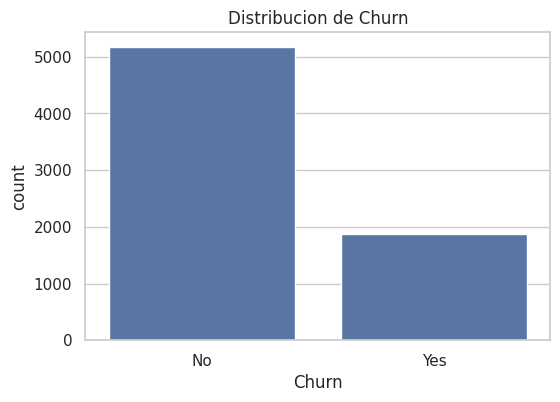

In [18]:
churn_counts = df_model["Churn"].value_counts()
churn_pct = df_model["Churn"].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({"conteo": churn_counts, "porcentaje": churn_pct}))

imbalance_ratio = churn_counts.max() / churn_counts.min()
print(f"Ratio clase mayoritaria/minoritaria: {imbalance_ratio:.2f}")
if imbalance_ratio >= 1.5:
    print("Existe desbalance moderado/alto. Se recomienda priorizar Recall/F1 de churn y considerar tecnicas de balanceo.")
else:
    print("Desbalance bajo. Aun asi, evaluar Recall y F1 para la clase churn.")

plt.figure(figsize=(6, 4))
sns.countplot(data=df_model, x="Churn", order=["No", "Yes"])
plt.title("Distribucion de Churn")
plt.show()

## 4) Analisis de correlacion (variables numericas)

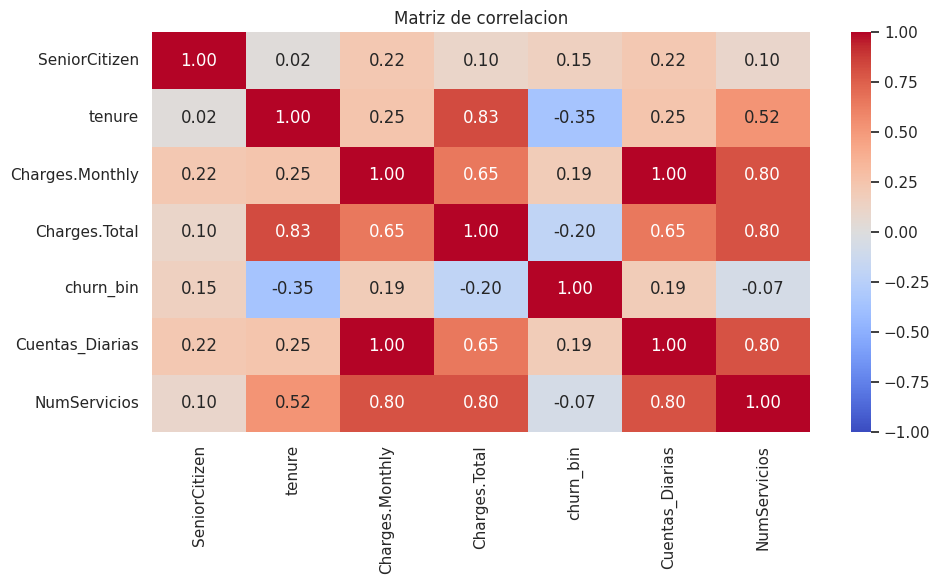

Top correlaciones con churn_bin:


,corr_con_churn
tenure,-0.352229
Charges.Total,-0.199484
Cuentas_Diarias,0.193412
Charges.Monthly,0.193356
SeniorCitizen,0.150889
NumServicios,-0.067264


In [19]:
numeric_cols = df_model.select_dtypes(include=["number"]).columns.tolist()
if "churn_bin" not in numeric_cols:
    numeric_cols.append("churn_bin")

corr = df_model[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()

target_corr = corr["churn_bin"].drop("churn_bin").sort_values(key=np.abs, ascending=False)
print("Top correlaciones con churn_bin:")
display(target_corr.head(10).to_frame("corr_con_churn"))

## 5) Analisis dirigido

Se evalua especificamente:
- `tenure` x `Churn`
- `Charges.Total` x `Churn`

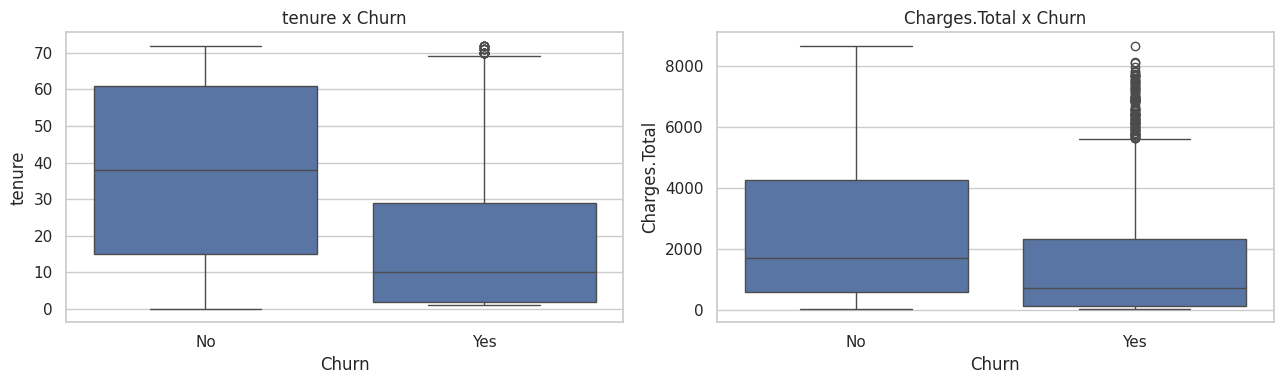

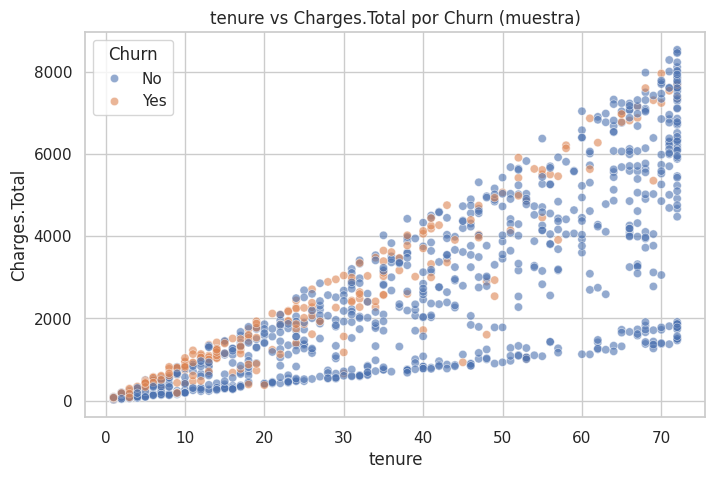

,tenure,Charges.Total
Churn,,
No,38.0,1683.60
Yes,10.0,703.55


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df_model, x="Churn", y="tenure", order=["No", "Yes"], ax=axes[0])
axes[0].set_title("tenure x Churn")

sns.boxplot(data=df_model, x="Churn", y="Charges.Total", order=["No", "Yes"], ax=axes[1])
axes[1].set_title("Charges.Total x Churn")

plt.tight_layout()
plt.show()

sample_df = df_model.sample(min(1200, len(df_model)), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample_df, x="tenure", y="Charges.Total", hue="Churn", alpha=0.6)
plt.title("tenure vs Charges.Total por Churn (muestra)")
plt.show()

display(df_model.groupby("Churn")[["tenure", "Charges.Total"]].median())

## 6) Separacion de datos (train/test)

In [21]:
target_col = "churn_bin"
drop_cols = [c for c in ["Churn"] if c in df_model.columns]
X = df_model.drop(columns=drop_cols + [target_col])
y = df_model[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Se uso division 80/20 con estratificacion para preservar proporcion de churn.")

X_train: (5634, 21), X_test: (1409, 21)
Se uso division 80/20 con estratificacion para preservar proporcion de churn.


## 7) Preprocesamiento y modelos

Se entrenan 2 modelos:
- Regresion Logistica (sensible a escala, con estandarizacion).
- Random Forest (no sensible a escala, sin estandarizacion).

El encoding de categoricas se realiza con `OneHotEncoder` en ambos casos.

In [22]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_noscale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_scaled = ColumnTransformer(transformers=[
    ("num", numeric_transformer_scaled, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

preprocess_noscale = ColumnTransformer(transformers=[
    ("num", numeric_transformer_noscale, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

log_reg_model = Pipeline(steps=[
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(max_iter=300, class_weight="balanced", random_state=42)),
])

rf_model = Pipeline(steps=[
    ("preprocess", preprocess_noscale),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )),
])

models = {
    "LogisticRegression": log_reg_model,
    "RandomForest": rf_model,
}

## 8) Evaluacion de modelos

Metricas: exactitud, precision, recall, F1 y matriz de confusion.

Adicionalmente, se reporta score en train/test para revisar overfitting o underfitting.

In [23]:
results = []
trained_models = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_pred = pipe.predict(X_test)
    train_score = pipe.score(X_train, y_train)
    test_score = pipe.score(X_test, y_test)

    metrics_row = {
        "modelo": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "train_score": train_score,
        "test_score": test_score,
        "gap_train_test": train_score - test_score,
    }
    results.append(metrics_row)

    print(f"\n===== {name} =====")
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, y_pred))
    print("Reporte de clasificacion:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False).reset_index(drop=True)
display(results_df.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "train_score": "{:.4f}",
    "test_score": "{:.4f}",
    "gap_train_test": "{:.4f}",
}))


===== LogisticRegression =====
Matriz de confusion:
[[749 286]
 [ 80 294]]
Reporte de clasificacion:
              precision    recall  f1-score   support

           0     0.9035    0.7237    0.8036      1035
           1     0.5069    0.7861    0.6164       374

    accuracy                         0.7402      1409
   macro avg     0.7052    0.7549    0.7100      1409
weighted avg     0.7982    0.7402    0.7539      1409


===== RandomForest =====
Matriz de confusion:
[[868 167]
 [146 228]]
Reporte de clasificacion:
              precision    recall  f1-score   support

           0     0.8560    0.8386    0.8472      1035
           1     0.5772    0.6096    0.5930       374

    accuracy                         0.7779      1409
   macro avg     0.7166    0.7241    0.7201      1409
weighted avg     0.7820    0.7779    0.7798      1409



,modelo,accuracy,precision,recall,f1,train_score,test_score,gap_train_test
0,LogisticRegression,0.7402,0.5069,0.7861,0.6164,0.7519,0.7402,0.0116
1,RandomForest,0.7779,0.5772,0.6096,0.5930,0.9409,0.7779,0.1630


## 9) Importancia de variables

Top variables por magnitud de coeficiente (LogisticRegression):


,feature,coef
1,num__tenure,-1.272893
40,cat__Contract_Two year,-0.764077
38,cat__Contract_Month-to-month,0.645767
18,cat__InternetService_Fiber optic,0.597419
3,num__Charges.Total,0.597368
17,cat__InternetService_DSL,-0.557766
2,num__Charges.Monthly,-0.309624
45,cat__PaymentMethod_Electronic check,0.262297
41,cat__PaperlessBilling_No,-0.259855
4,num__Cuentas_Diarias,-0.258457


Top variables por importancia (RandomForest):


,feature,importance
1,num__tenure,0.122186
3,num__Charges.Total,0.115347
38,cat__Contract_Month-to-month,0.093421
2,num__Charges.Monthly,0.083396
4,num__Cuentas_Diarias,0.071835
40,cat__Contract_Two year,0.039784
20,cat__OnlineSecurity_No,0.038632
29,cat__TechSupport_No,0.037421
45,cat__PaymentMethod_Electronic check,0.029071
18,cat__InternetService_Fiber optic,0.026903


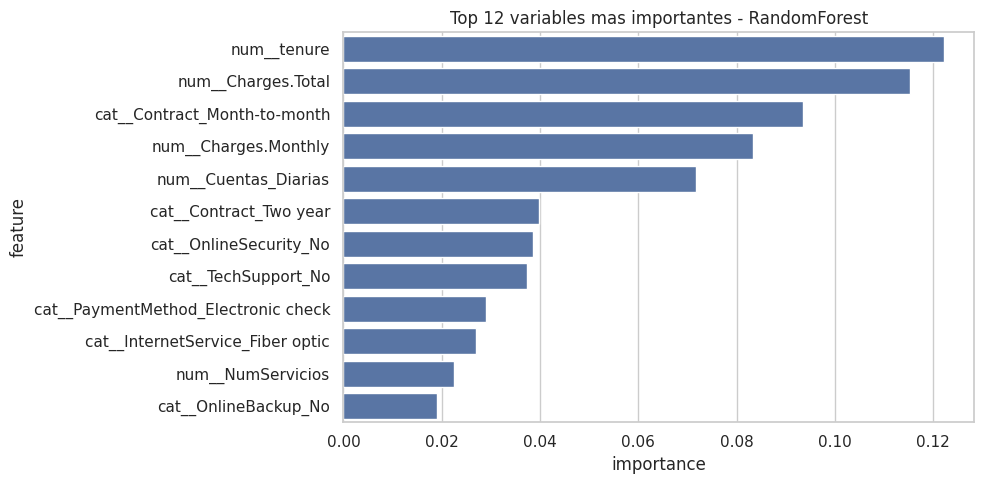

In [24]:
# 9.1 Coeficientes de Regresion Logistica
lr_pipe = trained_models["LogisticRegression"]
lr_pre = lr_pipe.named_steps["preprocess"]
lr_model = lr_pipe.named_steps["model"]

feature_names_lr = lr_pre.get_feature_names_out()
coef_lr = lr_model.coef_.ravel()
coef_df = (
    pd.DataFrame({"feature": feature_names_lr, "coef": coef_lr})
    .assign(abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

print("Top variables por magnitud de coeficiente (LogisticRegression):")
display(coef_df[["feature", "coef"]].head(15))

# 9.2 Importancia de Random Forest
rf_pipe = trained_models["RandomForest"]
rf_pre = rf_pipe.named_steps["preprocess"]
rf_model = rf_pipe.named_steps["model"]

feature_names_rf = rf_pre.get_feature_names_out()
rf_imp = rf_model.feature_importances_
imp_df = (
    pd.DataFrame({"feature": feature_names_rf, "importance": rf_imp})
    .sort_values("importance", ascending=False)
)

print("Top variables por importancia (RandomForest):")
display(imp_df.head(15))

plt.figure(figsize=(10, 5))
sns.barplot(data=imp_df.head(12), x="importance", y="feature", orient="h")
plt.title("Top 12 variables mas importantes - RandomForest")
plt.tight_layout()
plt.show()

## 10) Conclusiones estrategicas

Esta celda resume automaticamente desempeno y hallazgos para toma de decisiones.

In [25]:
best_model = results_df.iloc[0]
best_name = best_model["modelo"]

def fit_diagnosis(gap):
    if gap > 0.08:
        return "posible overfitting"
    if gap < 0.02:
        return "ajuste equilibrado"
    return "ligero sobreajuste, controlable"

diag_lines = []
for _, row in results_df.iterrows():
    diag_lines.append(
        f"- {row['modelo']}: train={row['train_score']:.3f}, test={row['test_score']:.3f}, gap={row['gap_train_test']:.3f} -> {fit_diagnosis(row['gap_train_test'])}"
    )

top_lr = coef_df[["feature", "coef"]].head(5).to_string(index=False)
top_rf = imp_df[["feature", "importance"]].head(5).to_string(index=False)

print("RESUMEN EJECUTIVO")
print(f"Modelo recomendado por F1: {best_name}")
print(f"Accuracy: {best_model['accuracy']:.3f} | Precision: {best_model['precision']:.3f} | Recall: {best_model['recall']:.3f} | F1: {best_model['f1']:.3f}")
print("\nDiagnostico de ajuste:")
print("\n".join(diag_lines))

print("\nVariables clave (LogisticRegression):")
print(top_lr)
print("\nVariables clave (RandomForest):")
print(top_rf)

print("\nEstrategias de retencion sugeridas:")
print("1) Priorizar clientes de alto riesgo en contrato mensual (month-to-month) con ofertas de permanencia.")
print("2) Crear acciones tempranas para clientes con baja antiguedad (tenure bajo), donde se concentra mayor churn.")
print("3) Revisar estructura de cobros y comunicacion de valor para segmentos con mayor carga economica.")
print("4) Integrar el modelo en un monitoreo periodico para activar campanas preventivas.")

RESUMEN EJECUTIVO
Modelo recomendado por F1: LogisticRegression
Accuracy: 0.740 | Precision: 0.507 | Recall: 0.786 | F1: 0.616

Diagnostico de ajuste:
- LogisticRegression: train=0.752, test=0.740, gap=0.012 -> ajuste equilibrado
- RandomForest: train=0.941, test=0.778, gap=0.163 -> posible overfitting

Variables clave (LogisticRegression):
                         feature      coef
                     num__tenure -1.272893
          cat__Contract_Two year -0.764077
    cat__Contract_Month-to-month  0.645767
cat__InternetService_Fiber optic  0.597419
              num__Charges.Total  0.597368

Variables clave (RandomForest):
                     feature  importance
                 num__tenure    0.122186
          num__Charges.Total    0.115347
cat__Contract_Month-to-month    0.093421
        num__Charges.Monthly    0.083396
        num__Cuentas_Diarias    0.071835

Estrategias de retencion sugeridas:
1) Priorizar clientes de alto riesgo en contrato mensual (month-to-month) con ofert